In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import datetime
import pandas as pd
import random
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv('nifty.csv', index_col=0, low_memory=False)

In [5]:
df.head()

,Close,High,Low,Open,Volume,date,weekday,month
0,5993.250000,6006.049805,5982.000000,5982.600098,0,02-01-2013,2,1
1,6009.500000,6017.000000,5986.549805,6015.799805,0,03-01-2013,3,1
2,6016.149902,6020.750000,5981.549805,6011.950195,0,04-01-2013,4,1
3,5988.399902,6042.149902,5977.149902,6042.149902,0,07-01-2013,0,1
4,6001.700195,6007.049805,5964.399902,5983.450195,0,08-01-2013,1,1


In [6]:
# Fix: Assign the modified values directly to df['Volume']
df['Volume'] = df['Volume'].replace(0, np.nan)  # Convert 0 to NaN
df['Volume'] = df['Volume'].ffill()  # Forward fill NaN (alternative to fillna with method)

In [7]:
# Compute percentage change in tomorrow's Open price relative to today's Close
df["p_co"] = ((df["Open"].shift(-1)-df["Close"]) / df["Close"]) * 100

In [8]:
df["p_co"].describe()

count    2944.000000
mean        0.121685
std         0.610568
min        -9.144755
25%        -0.082979
50%         0.150933
75%         0.381853
max         4.484277
Name: p_co, dtype: float64

In [9]:
# Compute MACD (Default: Fast=12, Slow=26, Signal=9)
macd_df = df.ta.macd(close="Close", fast=12, slow=26, signal=9)

# Add MACD values to the main DataFrame
df = pd.concat([df, macd_df], axis=1)


In [10]:
# Compute RSI (Default length = 14)
df["RSI"] = df.ta.rsi(close="Close", length=14)

In [11]:
df['SMA_10'] = ta.sma(df['Close'], length=10)  # 10-day SMA
df['SMA_50'] = ta.sma(df['Close'], length=50)  # 50-day SMA

In [12]:
df['EMA_10'] = ta.ema(df['Close'], length=10)  # 10-day EMA
df['EMA_50'] = ta.ema(df['Close'], length=50)  # 50-day EMA

In [13]:
# Convert 'Date' column to datetime (Modify column name if needed)
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

# Set 'Date' as index (Required for VWAP)
df.set_index("date", inplace=True)

# Compute VWAP
df["VWAP"] = df.ta.vwap(high="High", low="Low", close="Close", volume="Volume")

In [14]:
# Compute percentage change in tomorrow's Open price relative to today's Close
df["oc"] = ((df["Open"]- df["Close"]) / df["Open"]) * 100

In [15]:
# Compute Bollinger Bands with a 20-day window
df.ta.bbands(close='close', length=20, append=True)

,BBL_20_2.0,BBM_20_2.0,BBU_20_2.0,BBB_20_2.0,BBP_20_2.0
date,,,,,
2013-01-02,NaN,NaN,NaN,NaN,NaN
2013-01-03,NaN,NaN,NaN,NaN,NaN
2013-01-04,NaN,NaN,NaN,NaN,NaN
2013-01-07,NaN,NaN,NaN,NaN,NaN
2013-01-08,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2024-12-23,23677.155127,24339.255078,25001.355029,5.440593,0.057615
2024-12-24,23604.001008,24315.912597,25027.824187,5.855520,0.086843
2024-12-26,23536.195672,24289.677539,25043.159406,6.204132,0.142010


In [16]:
# Compute 14-period ATR (default)
df.ta.atr(length=14, append=True)

date
2013-01-02           NaN
2013-01-03           NaN
2013-01-04           NaN
2013-01-07           NaN
2013-01-08           NaN
                 ...    
2024-12-23    301.432105
2024-12-24    292.936955
2024-12-26    286.362914
2024-12-27    279.383448
2024-12-30    282.002404
Name: ATRr_14, Length: 2945, dtype: float64

In [17]:
print(df[55:].isna().sum())  # Count of NaN values per column

Close            0
High             0
Low              0
Open             0
Volume           0
weekday          0
month            0
p_co             1
MACD_12_26_9     0
MACDh_12_26_9    0
MACDs_12_26_9    0
RSI              0
SMA_10           0
SMA_50           0
EMA_10           0
EMA_50           0
VWAP             0
oc               0
BBL_20_2.0       0
BBM_20_2.0       0
BBU_20_2.0       0
BBB_20_2.0       0
BBP_20_2.0       0
ATRr_14          0
dtype: int64


In [18]:
df_subset = df.iloc[55:-1]  # Select rows from index 35 onwards
print(df_subset[df_subset.isna().any(axis=1)])

Empty DataFrame
Columns: [Close, High, Low, Open, Volume, weekday, month, p_co, MACD_12_26_9, MACDh_12_26_9, MACDs_12_26_9, RSI, SMA_10, SMA_50, EMA_10, EMA_50, VWAP, oc, BBL_20_2.0, BBM_20_2.0, BBU_20_2.0, BBB_20_2.0, BBP_20_2.0, ATRr_14]
Index: []

[0 rows x 24 columns]


In [19]:
# Check for Inf values
print(np.isinf(df_subset).sum())  # Count of Inf values per column

Close            0
High             0
Low              0
Open             0
Volume           0
weekday          0
month            0
p_co             0
MACD_12_26_9     0
MACDh_12_26_9    0
MACDs_12_26_9    0
RSI              0
SMA_10           0
SMA_50           0
EMA_10           0
EMA_50           0
VWAP             0
oc               0
BBL_20_2.0       0
BBM_20_2.0       0
BBU_20_2.0       0
BBB_20_2.0       0
BBP_20_2.0       0
ATRr_14          0
dtype: int64


In [20]:
df['Target']=np.where(df['oc'].values<-0.15,0,np.where(df['oc'].values<0.15,1,2))
df['Target']=df['Target'].shift(-1)
# Fill NaN with a placeholder (e.g., -1) before converting to integer
df['Target'] = df['Target'].fillna(-1).astype(int)

In [21]:
print(df['Target'].dtype)  # Should output 'int32' or 'int64'

int32


In [22]:
 df["cnnstate"] = None

In [23]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'weekday', 'month', 'p_co',
       'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'RSI', 'SMA_10',
       'SMA_50', 'EMA_10', 'EMA_50', 'VWAP', 'oc', 'BBL_20_2.0', 'BBM_20_2.0',
       'BBU_20_2.0', 'BBB_20_2.0', 'BBP_20_2.0', 'ATRr_14', 'Target',
       'cnnstate'],
      dtype='object')

In [24]:
df.tail(2)

,Close,High,Low,Open,Volume,weekday,month,p_co,MACD_12_26_9,MACDh_12_26_9,...,VWAP,oc,BBL_20_2.0,BBM_20_2.0,BBU_20_2.0,BBB_20_2.0,BBP_20_2.0,ATRr_14,Target,cnnstate
date,,,,,,,,,,,,,,,,,,,,,
2024-12-27,23813.40039,23938.84961,23800.59961,23801.40039,176800.0,4,12,-0.069289,-141.269558,-82.472184,...,23850.94987,-0.050417,23519.919649,24284.640039,25049.360429,6.297976,0.191888,279.383448,2,None
2024-12-30,23644.90039,23915.34961,23599.30078,23796.90039,364900.0,0,12,NaN,-160.382570,-81.268156,...,23719.85026,0.638739,23448.189814,24260.330078,25072.470342,6.695212,0.121106,282.002404,-1,None


In [25]:
# Drop the last row (as it has no next-day price)
df = df[:-1]

In [26]:
df = df[54:].reset_index(drop=False)  # Drop first 55 rows and reset index

In [27]:
df.head()

,date,Close,High,Low,Open,Volume,weekday,month,p_co,MACD_12_26_9,...,VWAP,oc,BBL_20_2.0,BBM_20_2.0,BBU_20_2.0,BBB_20_2.0,BBP_20_2.0,ATRr_14,Target,cnnstate
0,2013-03-19,5745.950195,5863.600098,5724.299805,5859.500000,182300.0,1,3,-0.093986,-20.919208,...,5777.950033,1.937875,5677.563483,5832.605029,5987.646576,5.316374,0.220543,75.372734,2,None
1,2013-03-20,5694.399902,5745.299805,5682.299805,5740.549805,187600.0,2,3,0.201953,-31.332167,...,5707.333171,0.803928,5662.691947,5820.172534,5977.653121,5.411544,0.100673,74.520964,2,None
2,2013-03-21,5658.750000,5757.750000,5647.950195,5705.899902,179200.0,3,3,0.018552,-41.977273,...,5688.150065,0.826336,5638.941809,5810.497534,5982.053259,5.905027,0.057731,77.081241,1,None
3,2013-03-22,5651.350098,5691.450195,5631.799805,5659.799805,165300.0,4,3,0.990024,-50.429388,...,5658.200033,0.149293,5616.745005,5800.550049,5984.355093,6.337504,0.094135,75.817684,2,None
4,2013-03-25,5633.850098,5718.399902,5624.399902,5707.299805,150400.0,0,3,-0.356774,-57.872733,...,5658.883301,1.286943,5593.886613,5789.505054,5985.123494,6.757691,0.102147,77.134317,0,None


In [28]:
# Select features (5 indicators)
features = ['weekday', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'RSI', 'VWAP', 'p_co', 'oc',
       'BBL_20_2.0', 'BBM_20_2.0', 'BBU_20_2.0', 'BBB_20_2.0', 'BBP_20_2.0','ATRr_14','SMA_10','SMA_50', 'EMA_10', 'EMA_50']
target = 'Target'

In [29]:
df['Target'].shape

(2890,)

In [30]:
len(features)

18

In [31]:
# Normalize data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

In [32]:
# Convert data into sequences for CNN
sequence_length = 20  # Use past 20 days to predict next day

def create_sequences(data, features, target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[features].iloc[i:i+seq_length].values)  # Shape (20, 16)
        y.append(data[target].iloc[i+seq_length])  # Target label for the next day
    X = np.array(X)
    y = np.array(y)
    
    # Reshape X for CNN (add channel dimension)
    X = np.expand_dims(X, axis=-1)  # Shape (num_samples, 20, 16, 1)
    
    return X, y


In [33]:
X, y = create_sequences(df, features, target, sequence_length)

In [34]:
df.shape

(2890, 27)

In [35]:
X.shape

(2870, 20, 18, 1)

In [36]:
y.shape

(2870,)

In [37]:
type(y)

numpy.ndarray

In [38]:
type(X)

numpy.ndarray

In [39]:
X[0].shape

(20, 18, 1)

In [40]:
X[0][0].shape

(18, 1)

In [41]:
X[0][0]

array([[0.25      ],
       [0.67602727],
       [0.57713026],
       [0.6534017 ],
       [0.36053976],
       [0.02563839],
       [0.66408009],
       [0.69734767],
       [0.02819666],
       [0.01795391],
       [0.01307328],
       [0.07872046],
       [0.3778207 ],
       [0.02701777],
       [0.02331674],
       [0.01197069],
       [0.02061023],
       [0.01468981]])

In [42]:
# Define the split index (80% train, 20% test)
split_index = int(0.8 * len(X))

# Train and test split
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Print dataset shapes
print("X_train shape:", X_train.shape)  # (train_samples, 20, 16, 1)
print("y_train shape:", y_train.shape)  # (train_samples,)
print("X_test shape:", X_test.shape)    # (test_samples, 20, 16, 1)
print("y_test shape:", y_test.shape)    # (test_samples,)

X_train shape: (2296, 20, 18, 1)
y_train shape: (2296,)
X_test shape: (574, 20, 18, 1)
y_test shape: (574,)


In [43]:
# Print dataset shape
print(f"Training data shape: {X_train.shape}, Labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Labels shape: {y_test.shape}")

Training data shape: (2296, 20, 18, 1), Labels shape: (2296,)
Testing data shape: (574, 20, 18, 1), Labels shape: (574,)


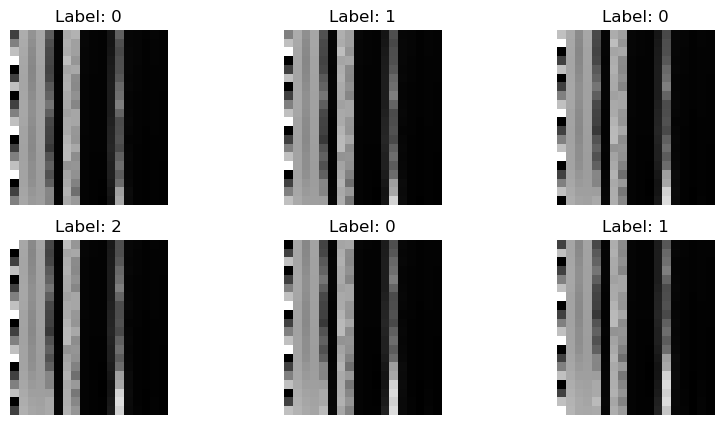

In [44]:
# Display some images
plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [45]:
from tensorflow.keras import layers, models, Input

model = models.Sequential([
    Input(shape=(20, 18, 1)),  # Explicit Input layer
    layers.Conv2D(32, (3, 3),strides=(1,1), activation='relu'), 
    #layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')  # Output layer
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 18, 16, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 12, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 7, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 5, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 174,851 (683.01 KB)

 Trainable params: 174,851 (683.01 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [47]:
history = model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test))

Epoch 1/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4125 - loss: 1.0589 - val_accuracy: 0.3624 - val_loss: 1.1485
Epoch 2/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4258 - loss: 1.0424 - val_accuracy: 0.3624 - val_loss: 1.0968
Epoch 3/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4289 - loss: 1.0266 - val_accuracy: 0.3937 - val_loss: 1.1733
Epoch 4/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4288 - loss: 1.0378 - val_accuracy: 0.3624 - val_loss: 1.1630
Epoch 5/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4305 - loss: 1.0388 - val_accuracy: 0.3937 - val_loss: 1.0983
Epoch 6/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4319 - loss: 1.0351 - val_accuracy: 0.3937 - val_loss: 1.1205
Epoch 7/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4320 - loss: 1.0235 - val_accuracy: 0.3937 - val_loss: 1.0972
Epoch 8/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4409 - loss: 1.0271 - val_accuracy: 0.

In [48]:
# Make a prediction
predicted = model.predict(X)
print(predicted)
#print("Predicted Trend:", "UP" if predicted[0] > 0.5 else "DOWN")

90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
[[9.9999881e-01 1.2434766e-08 1.2181890e-06]
 [7.3189632e-08 9.9999988e-01 1.0631952e-16]
 [9.9999607e-01 1.4287210e-14 3.9351353e-06]
 ...
 [9.9477023e-01 2.8800522e-04 4.9416977e-03]
 [2.8464754e-07 9.9999976e-01 1.0482149e-11]
 [7.9982422e-02 9.2001760e-01 1.3767304e-12]]


In [49]:
# Convert probabilities to class labels
predicted_classes = np.argmax(predicted, axis=1)  # Get the index of the max value per row

In [50]:
predicted_classes.shape

(2870,)

In [51]:
# Get unique elements and their frequencies
unique_elements, counts = np.unique(predicted_classes, return_counts=True)

# Display results
for element, count in zip(unique_elements, counts):
    print(f"Element: {element}, Frequency: {count}")

Element: 0, Frequency: 1138
Element: 1, Frequency: 408
Element: 2, Frequency: 1324


In [52]:
df.shape

(2890, 27)

In [53]:
df.iloc[20:, df.columns.get_loc("cnnstate")] = predicted_classes

In [54]:
# Compute percentage change in tomorrow's Open price relative to today's Close
df["p_co"] = ((df["Open"].shift(-1)-df["Close"]) / df["Close"]) * 100

In [55]:
# Apply condition, keeping NaNs unchanged
df['state2d'] = np.where(df['p_co'] > 0, df['cnnstate'] + 3, df['cnnstate'])

In [56]:
df['state2d'].describe()

count     2870
unique       6
top          5
freq       896
Name: state2d, dtype: int64

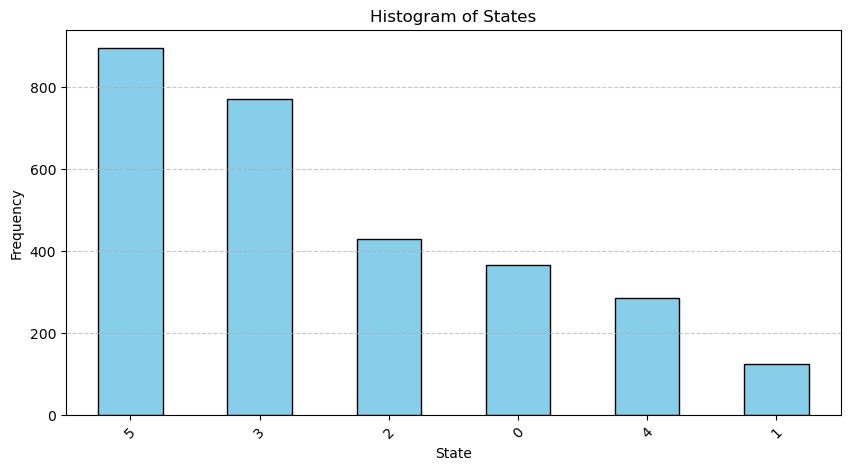

In [57]:
# Plot histogram for categorical data
df['state2d'].value_counts().plot(kind='bar', figsize=(10, 5), color='skyblue', edgecolor='black')

plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('Histogram of States')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [58]:
#df.index = pd.to_datetime(df.index)
df = df.reset_index(drop=True)
df.to_csv('tempcnn.csv', index=True) 